# Statewide races

Note: 'current' results are currently pointing to 2022 results, so as to be able to verify the model is working.

In [33]:
import pandas as pd

regions_nonmetro = pd.read_csv('./regions/regions_nonmetro.csv', index_col='County')
regions_nonmetro

,Region,Subregion
County,,
Banks,East,Outer East Georgia
Barrow,East,Metro Athens
Clarke,East,Metro Athens
Elbert,East,Outer East Georgia
Franklin,East,Outer East Georgia
...,...,...
Heard,West,Newnan-LaGrange
Meriwether,West,Newnan-LaGrange
Paulding,West,Carrollton-Paulding


Text(0.5, 1.0, 'Non-Metro Regions')

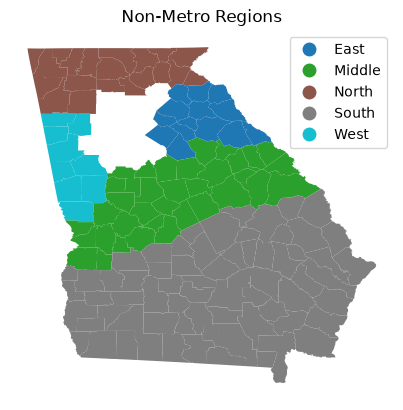

In [34]:
import utils

counties = utils.import_county_map()
counties['Region'] = regions_nonmetro['Region']
regions = counties['Region'].unique()
ax = counties.plot(column='Region', legend=True)
ax.set_axis_off()
ax.set_title('Non-Metro Regions')

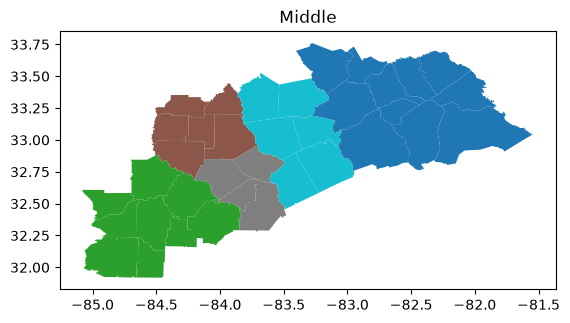

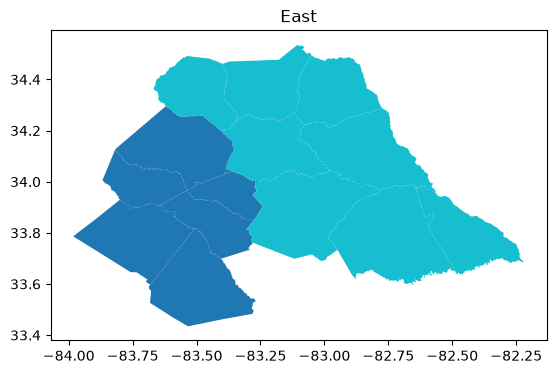

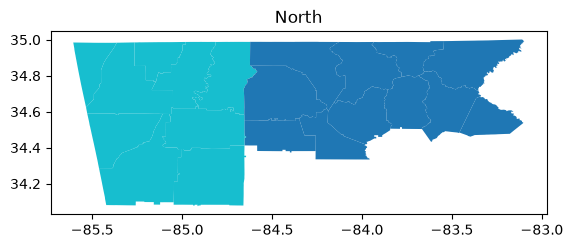

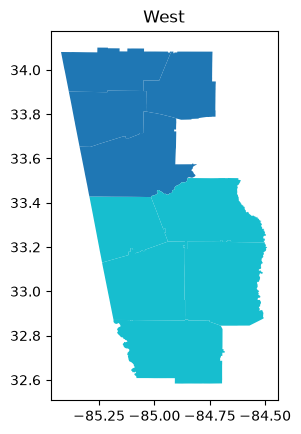

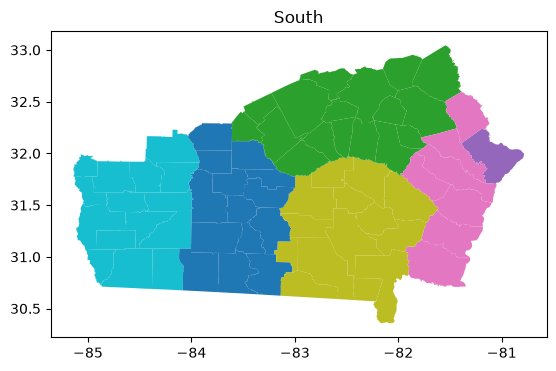

In [35]:
counties['Subregion'] = regions_nonmetro['Subregion']

for region in regions:
    if str(region) == 'nan':
        continue
    counties_f = counties[counties['Region'] == region]
    ax = counties_f.plot(column='Subregion')#, legend=True)
    ax.set_title(region)


In [36]:
def import_historical(year, office, metro=False):
    ext = '_metro' if metro else ''
    unit = ['County', 'Precinct'] if metro else ['County']
    data = pd.read_csv(f'./data/{year}_{office}{ext}.csv', index_col=[*unit, 'Vote Method'])
    return data

In [37]:
def sort_and_share(res):
    res = res.sort_values(by='Votes', ascending=False)
    res['Votes'] = res['Votes'].astype(int)
    res['Share'] = (res['Votes'] / res['Votes'].sum() * 100)
    return res

def display_single_results(df, writein=0):
    res = df.sum()
    res = pd.DataFrame(res, columns=['Votes'])
    if writein > 0:
        res.loc['Write-in', 'Votes'] = writein
    return sort_and_share(res)

# Metro GIS

In [38]:
import pandas as pd
import geopandas

metro_prec_data = geopandas.read_file('./regions/regions_metro.json')
metro_prec_data[metro_prec_data['Election'].isin(['2018', '2022', '*'])]
metro_prec_data = metro_prec_data.rename(columns={'index': 'Precinct'})

metro_counties = metro_prec_data['County'].values.unique()

# Sanitizing for 2022
def sanitize_gwinnett_2022(x):
    return ' '.join(x.split(' ')[1:])
metro_prec_data.loc[metro_prec_data['County'] == 'Gwinnett', 'Precinct'] = \
    metro_prec_data.loc[metro_prec_data['County'] == 'Gwinnett', 'Precinct'].apply(sanitize_gwinnett_2022)

def sanitize_hall_and_newton_2022(x):
    return '-'.join(x.split('-')[1:])
metro_prec_data.loc[metro_prec_data['County'] == 'Hall', 'Precinct'] = \
    metro_prec_data.loc[metro_prec_data['County'] == 'Hall', 'Precinct'].apply(sanitize_hall_and_newton_2022)

metro_prec_data['Precinct'] = \
    metro_prec_data['Precinct'].apply(lambda x: x.upper())

metro_prec_data = metro_prec_data.set_index(['County', 'Precinct', 'Election'], drop=False)
metro_prec_data = metro_prec_data.rename(
{
    'MT. BETHEL 01': 'MOUNT BETHEL 01',
    'MT. BETHEL 03': 'MOUNT BETHEL 03',
    'MT. BETHEL 04': 'MOUNT BETHEL 04',
    'CHAMBLEE ': 'CHAMBLEE',
    'BOULDERCREST ROAD': 'BOULDERCREST RD',
    'AVONDALE HIGH': 'AVONDALE HIGH - 04',
})
metro_prec_data

Precinct    County  \
County   Precinct    Election                          
Cherokee AIR ACRES   2026        AIR ACRES  Cherokee   
         ARNOLD MILL 2026      ARNOLD MILL  Cherokee   
         AVERY       2026            AVERY  Cherokee   
         BALL GROUND 2026      BALL GROUND  Cherokee   
         BASCOMB     2026          BASCOMB  Cherokee   
...                                    ...       ...   
Rockdale HI          2018               HI  Rockdale   
         LO          2018               LO  Rockdale   
         BA          2018               BA  Rockdale   
         ST          2018               ST  Rockdale   
         HC          2018               HC  Rockdale   

                                                Reporting Group  \
County   Precinct    Election                                     
Cherokee AIR ACRES   2026                             AIR ACRES   
         ARNOLD MILL 2026                           ARNOLD MILL   
         AVERY       2026                                 AVERY   
         BALL GROUND 2026                           BALL GROUND   
         BASCOMB     2026                               BASCOMB   
...                                                         ...   
Rockdale HI          2018      HI-MI Precinct Reporting Group 0   
         LO          2018                                    LO   
         BA          2018                                    BA   
         ST          2018                                    ST   
         HC          2018      HC-MA Precinct Reporting Group 0   

                                                Subregion Election  \
County   Precinct    Election                                        
Cherokee AIR ACRES   2026                   Holly Springs     2026   
         ARNOLD MILL 2026                   Holly Springs     2026   
         AVERY       2026      Canton-Waleska-Ball Ground     2026   
         BALL GROUND 2026      Canton-Waleska-Ball Ground     2026   
         BASCOMB     2026                       Woodstock     2026   
...                                                   ...      ...   
Rockdale HI          2018                        Rockdale     2018   
         LO          2018                        Rockdale     2018   
         BA          2018                        Rockdale     2018   
         ST          2018                        Rockdale     2018   
         HC          2018                        Rockdale     2018   

                              Precinct ID               Region  \
County   Precinct    Election                                    
Cherokee AIR ACRES   2026          5144.0  North Metro Atlanta   
         ARNOLD MILL 2026          5146.0  North Metro Atlanta   
         AVERY       2026          8728.0  North Metro Atlanta   
         BALL GROUND 2026          8743.0  North Metro Atlanta   
         BASCOMB     2026          5130.0  North Metro Atlanta   
...                                   ...                  ...   
Rockdale HI          2018            2344  South Metro Atlanta   
         LO          2018            2607  South Metro Atlanta   
         BA          2018            2610  South Metro Atlanta   
         ST          2018            2611  South Metro Atlanta   
         HC          2018            2612  South Metro Atlanta   

                                                                        geometry  
County   Precinct    Election                                                     
Cherokee AIR ACRES   2026      POLYGON ((-84.4856 34.11594, -84.48539 34.1161...  
         ARNOLD MILL 2026      POLYGON ((-84.43107 34.10415, -84.43122 34.104...  
         AVERY       2026      POLYGON ((-84.36133 34.13702, -84.36177 34.137...  
         BALL GROUND 2026      POLYGON ((-84.39359 34.30172, -84.39349 34.301...  
         BASCOMB     2026      POLYGON ((-84.57311 34.15381, -84.57358 34.152...  
...                                                                          ...  

In [39]:
def agg_uniq(s: pd.Series):
    vals = s.values.unique()
    if len(vals) != 1:
        print(s)
        assert len(vals) == 1
    [val] = vals
    return val

metro_prec_data_rg_map = metro_prec_data.set_index(['County', 'Reporting Group'])
metro_prec_data_rg_map = metro_prec_data_rg_map[['Subregion', 'Region']]
metro_prec_data_rg_map = metro_prec_data_rg_map.groupby(metro_prec_data_rg_map.index).agg(agg_uniq)
metro_prec_data_rg_map.index = pd.MultiIndex.from_tuples(metro_prec_data_rg_map.index)
metro_prec_data_rg_map['geometry'] = \
    metro_prec_data[metro_prec_data['Election'].isin(['2022', '2018', '*'])] \
        .set_index(['County', 'Reporting Group']) \
        .dissolve(by=['County', 'Reporting Group'])['geometry']
metro_prec_data_rg_map.index = pd.Index(metro_prec_data_rg_map.index.map(lambda x: f'{x[1]}, {x[0]}'))
metro_prec_data_rg_map

,Subregion,Region,geometry
"AIR ACRES, Cherokee",Holly Springs,North Metro Atlanta,"POLYGON ((-84.48539 34.11611, -84.48523 34.116..."
"AIRPORT, Cherokee",Canton-Waleska-Ball Ground,North Metro Atlanta,"POLYGON ((-84.46594 34.25118, -84.46587 34.251..."
"ARNOLD MILL, Cherokee",Holly Springs,North Metro Atlanta,"POLYGON ((-84.43122 34.10421, -84.43128 34.104..."
"AVERY, Cherokee",Canton-Waleska-Ball Ground,North Metro Atlanta,"POLYGON ((-84.36177 34.13742, -84.36182 34.137..."
"BALL GROUND, Cherokee",Canton-Waleska-Ball Ground,North Metro Atlanta,"POLYGON ((-84.39349 34.30185, -84.39345 34.301..."
...,...,...,...
"OT, Rockdale",Rockdale,South Metro Atlanta,"MULTIPOLYGON (((-84.03401 33.66638, -84.03326 ..."
"RO, Rockdale",Rockdale,South Metro Atlanta,"MULTIPOLYGON (((-84.01687 33.65123, -84.01686 ..."
"SM, Rockdale",Rockdale,South Metro Atlanta,"POLYGON ((-84.10186 33.64054, -84.10002 33.643..."
"SP, Rockdale",Rockdale,South Metro Atlanta,"POLYGON ((-84.01437 33.62777, -84.01437 33.627..."


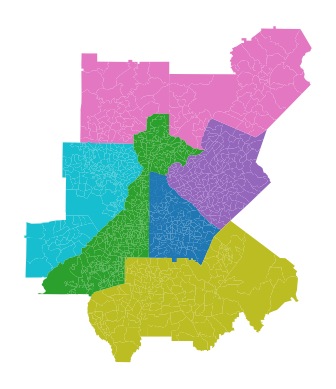

In [40]:
ax = geopandas.GeoDataFrame(metro_prec_data_rg_map).plot(legend=False, column='Region')
ax.set_axis_off()

# Misc

In [41]:
def fmt(df: pd.DataFrame):
    df = df.copy()
    if 'Votes' in df:
        df['Votes'] = df['Votes'].map(utils.format_votes)
    for col in df.columns:
        if 'Share' in col:
            df[col] = df[col].round(utils.STD_ROUND)
        if 'Swing' in col:
            df[col] = df[col].round(utils.STD_ROUND).map(utils.format_delta)
    return df

# Import results

More will need to go here once we can actually use the SoS's json files

# Governor

2018 gubernatorial election results.

In [42]:
prev = import_historical(2018, 'governor')
prev_table = display_single_results(prev, writein=81)
fmt(prev_table)

,Votes,Share
BRIAN KEMP (REP),"1,978,408",50.22
STACEY ABRAMS (DEM),"1,923,685",48.83
TED METZ (LIB),"37,235",0.95
Write-in,81,0.00


In [43]:
kemp2022 = 'Brian Kemp (I) (Rep)'
abrams2022 = 'Stacey Abrams (Dem)'
hazel2022 = 'Shane Hazel (Lib)'

kemp2018 = 'BRIAN KEMP  (REP)'
abrams2018 = 'STACEY ABRAMS  (DEM)'
metz2018 = 'TED METZ (LIB)'

race = 'governor'

#jackson2026 = 'Rick Jackson (Rep)'
#bottoms2026 = 'Keisha Lance Bottoms (Dem)'

winning_cand = prev_table.loc[kemp2018] # prev[kemp2022]
runner_up = prev_table.loc[abrams2018] # prev[abrams2022]

margin = winning_cand['Votes'] - runner_up['Votes']
margin_p = winning_cand['Share'] - runner_up['Share']
meta = {
    'Total Votes': utils.format_votes(prev_table['Votes'].sum()),
    'Margin': utils.format_votes(margin),
    'Margin (points)': margin_p.round(utils.STD_ROUND),
    'Swing required for Dem gain': (50 - runner_up['Share']).round(utils.STD_ROUND),
    'Two-party swing required for Dem plurality': (margin_p / 2).round(utils.STD_ROUND),
    'Two-party swing required for Dem gain': (((50 - runner_up['Share']) + (50 - winning_cand['Share'])) / 2).round(utils.STD_ROUND),
}
pd.Series(meta)

Total Votes                                   3,939,409
Margin                                         54,723.0
Margin (points)                                    1.39
Swing required for Dem gain                        1.17
Two-party swing required for Dem plurality         0.69
Two-party swing required for Dem gain              0.47
dtype: object

Below is the 2022 gubernatorial election results. Once model is "active", and reading 2026 results on election night, this table will show the results as counted up to that point. 

In [44]:
curr = import_historical(2022, race)
results_table = display_single_results(curr)

curr_dem = abrams2022
curr_rep = kemp2022
curr_lib = hazel2022
prev_dem = abrams2018
prev_rep = kemp2018
prev_lib = metz2018

results_table.loc[curr_rep, 'Swing'] = results_table.loc[curr_rep, 'Share'] - prev_table.loc[prev_rep, 'Share']
results_table.loc[curr_dem, 'Swing'] = results_table.loc[curr_dem, 'Share'] - prev_table.loc[prev_dem, 'Share']
results_table.loc[curr_lib, 'Swing'] = results_table.loc[curr_lib, 'Share'] - prev_table.loc[prev_lib, 'Share']

fmt(results_table)

,Votes,Share,Swing
Brian Kemp (I) (Rep),"2,111,572",53.41,+3.19
Stacey Abrams (Dem),"1,813,673",45.88,-2.96
Shane Hazel (Lib),"28,163",0.71,-0.23


In [45]:
[winning_cand, runner_up, _] = results_table.index.tolist()
margin = results_table.loc[winning_cand, 'Votes'] - results_table.loc[runner_up, 'Votes']
margin_p = results_table.loc[winning_cand, 'Share'] - results_table.loc[runner_up, 'Share']
tps = (results_table.loc[winning_cand, 'Swing'] - results_table.loc[runner_up, 'Swing']) / 2
quota = int(results_table['Votes'].sum() / 2) + 1
meta = {
    'Total Votes': utils.format_votes(results_table['Votes'].sum()),
    'Margin': utils.format_votes(margin),
    'Margin (points)': margin_p.round(utils.STD_ROUND),
    'Two-party swing': tps.round(utils.STD_ROUND),
    'Votes over runoff threshold': utils.format_votes(results_table.loc[winning_cand, 'Votes'] - quota)
}
pd.Series(meta)

Total Votes                    3,953,408
Margin                           297,899
Margin (points)                     7.54
Two-party swing                     3.07
Votes over runoff threshold      134,867
dtype: object

## Regional Swing Model

In [46]:
import model

def votes_table(votes: pd.DataFrame, votes_metro: pd.DataFrame, year: str):
    def find_prg(i):
        (county, prec, _) = i
        prec = prec.upper()
        election = '*' if (county, prec, '*') in metro_prec_data.index else year
        try:
            rg = metro_prec_data.loc[(county, prec, election), 'Reporting Group']
        except:
            print(f'{prec}, {county} ({year})')
            return f'None, {county}'
        return f'{rg}, {county}'
    votes_metro['Reporting Group'] = votes_metro.index.map(find_prg)
    votes_metro = votes_metro.groupby(['Reporting Group', 'Vote Method']).sum()
    votes = pd.concat([votes, votes_metro])
    votes.index = votes.index.set_names(['County/Reporting Group', 'Vote Method'])
    primary = votes.index.get_level_values('County/Reporting Group')

    metro_regions = metro_prec_data_rg_map['Region'].reindex(primary)
    county_regions = counties['Region'].reindex(primary)

    votes['Region'] = metro_regions.fillna(county_regions).to_numpy()
    return votes.reset_index().set_index(['Region', 'Vote Method', 'County/Reporting Group'])

prev_votes_county = pd.DataFrame(prev)
prev_votes_county = prev_votes_county.loc[~prev_votes_county.index.isin(metro_counties, level='County')]
prev_votes_metro = import_historical(2018, race, metro=True)
curr_votes_county = pd.DataFrame(curr)
cur_votes_county = curr_votes_county.loc[~curr_votes_county.index.isin(metro_counties, level='County')]
curr_votes_metro = import_historical(2022, race, metro=True)
prev_votes = votes_table(prev_votes_county, prev_votes_metro, '2018')
curr_votes = votes_table(curr_votes_county, curr_votes_metro, '2022')
df_votes = prev_votes.join(curr_votes, how='left')

prev_cands = prev_votes.columns
curr_cands = curr_votes.columns

swing_map = {
    prev_rep: curr_rep,
    prev_dem: curr_dem,
    prev_lib: curr_lib,
}

# TODO: There needs to be a way to look this up from the imported json results
df_votes['Reported?'] = True

regions = df_votes.index.get_level_values('Region').unique()
methods = df_votes.index.get_level_values('Vote Method').unique()

def project_m(df_votes1: pd.DataFrame, prev_cands: pd.Index[str], curr_cands: pd.Index[str], swing_map: dict[str]):
    df_votes_proj = pd.DataFrame(index=pd.MultiIndex.from_product([regions, methods, ['Previous', 'Current', 'Projection']], 
                                names=['Region', 'Vote Method', 'Field']),
                                columns=curr_cands)
    for region in regions:
        for method in methods:
            proj = model.project(df_votes1.loc[region].loc[method], prev_cands, curr_cands, swing_map)
            for field in proj.columns:
                df_votes_proj.loc[(region, method, field)] = proj[field]
    return df_votes_proj

df_votes_proj = project_m(df_votes, prev_cands, curr_cands, swing_map)

# Sanity check (TODO: change to assert)
df_votes_proj.reset_index().groupby('Field')[curr_cands].sum().loc['Current'] == results_table['Votes']
df_votes_proj.map(utils.format_votes)

ASHFORD DUNWOODY RD, DeKalb (2018)
ASHFORD DUNWOODY RD, DeKalb (2018)
ASHFORD DUNWOODY RD, DeKalb (2018)
ASHFORD DUNWOODY RD, DeKalb (2018)
ASHFORD PARK ELEM, DeKalb (2018)
ASHFORD PARK ELEM, DeKalb (2018)
ASHFORD PARK ELEM, DeKalb (2018)
ASHFORD PARK ELEM, DeKalb (2018)
ASHFORD PARKSIDE, DeKalb (2018)
ASHFORD PARKSIDE, DeKalb (2018)
ASHFORD PARKSIDE, DeKalb (2018)
ASHFORD PARKSIDE, DeKalb (2018)
AUSTIN, DeKalb (2018)
AUSTIN, DeKalb (2018)
AUSTIN, DeKalb (2018)
AUSTIN, DeKalb (2018)
AVONDALE, DeKalb (2018)
AVONDALE, DeKalb (2018)
AVONDALE, DeKalb (2018)
AVONDALE, DeKalb (2018)
AVONDALE HIGH - 05, DeKalb (2018)
AVONDALE HIGH - 05, DeKalb (2018)
AVONDALE HIGH - 05, DeKalb (2018)
AVONDALE HIGH - 05, DeKalb (2018)
BOULEVARD, DeKalb (2018)
BOULEVARD, DeKalb (2018)
BOULEVARD, DeKalb (2018)
BOULEVARD, DeKalb (2018)
BRIARWOOD, DeKalb (2018)
BRIARWOOD, DeKalb (2018)
BRIARWOOD, DeKalb (2018)
BRIARWOOD, DeKalb (2018)
BROCKETT, DeKalb (2018)
BROCKETT, DeKalb (2018)
BROCKETT, DeKalb (2018)
BROCKETT

Brian Kemp (I) (Rep) Stacey Abrams (Dem)  \
Region Vote Method      Field                                                 
South  Election Day     Previous                178,117             116,405   
                        Current                 180,612              76,377   
                        Projection              180,612              76,377   
       Advance Voting   Previous                192,908             106,883   
                        Current                 205,110             124,613   
...                                                 ...                 ...   
nan    Absentee by Mail Current                      25                 230   
                        Projection                   25                 230   
       Provisional      Previous                    184                 497   
                        Current                       1                   1   
                        Projection                    1                   1   

                                   Shane Hazel (Lib)  
Region Vote Method      Field                         
South  Election Day     Previous               2,718  
                        Current                2,155  
                        Projection             2,155  
       Advance Voting   Previous               1,242  
                        Current                1,451  
...                                              ...  
nan    Absentee by Mail Current                    4  
                        Projection                 4  
       Provisional      Previous                   7  
                        Current                    0  
                        Projection                 0  

[144 rows x 3 columns]

Below is the regional crosstable

In [47]:
def cross(df: pd.DataFrame, by: str, options): 
    shares = df.copy()
    shares = shares.reset_index().groupby([by, 'Field'])[curr_cands].sum()
    shares = shares.apply(lambda x: x / x.sum() * 100, axis=1)

    crosstable = \
        pd.DataFrame(index=pd.MultiIndex.from_product([options, ['Current', 'Projection']], names=[by, 'Field']),
                    columns=pd.MultiIndex.from_product([curr_cands, ['Share', 'Swing']]))
    for curr_cand in curr_cands:
        crosstable[(curr_cand, 'Share')] = shares[curr_cand]
        crosstable[(curr_cand, 'Swing')] = shares[curr_cand] - shares.xs('Previous', level=1)[curr_cand]
    return crosstable

reg_crosstable = cross(df_votes_proj, by='Region', options=regions)
metro_regs = ['Fulton', 'Gwinnett', 'DeKalb', 'North Metro Atlanta', 'South Metro Atlanta', 'West Metro Atlanta']
reg_crosstable['x'] = reg_crosstable.index.map(lambda x: 'Metro ATL' if x[0] in metro_regs else '')
reg_crosstable = reg_crosstable.reset_index().set_index(['x', 'Region', 'Field']).sort_index()
fmt(reg_crosstable)

Brian Kemp (I) (Rep)         \
                                                        Share  Swing   
x         Region              Field                                    
          East                Current                   69.94  +3.17   
                              Projection                69.94  +3.17   
          Middle              Current                   55.13  +3.09   
                              Projection                55.13  +3.09   
          North               Current                   82.24   +2.7   
                              Projection                82.24   +2.7   
          South               Current                   63.80  +3.07   
                              Projection                63.80  +3.07   
          West                Current                   71.16  +1.72   
                              Projection                71.16  +1.72   
          nan                 Current                     NaN    nan   
                              Projection                  NaN    nan   
Metro ATL DeKalb              Current                   14.05  +3.17   
                              Projection                14.05  +3.17   
          Fulton              Current                   29.91  +4.14   
                              Projection                29.91  +4.14   
          Gwinnett            Current                   44.44   +2.2   
                              Projection                44.44   +2.2   
          North Metro Atlanta Current                   73.88  +2.51   
                              Projection                73.88  +2.51   
          South Metro Atlanta Current                   34.08  +0.02   
                              Projection                34.08  +0.02   
          West Metro Atlanta  Current                   45.82  +1.88   
                              Projection                45.82  +1.88   

                                         Stacey Abrams (Dem)         \
                                                       Share  Swing   
x         Region              Field                                   
          East                Current                  29.29  -2.98   
                              Projection               29.29  -2.98   
          Middle              Current                  44.22   -3.0   
                              Projection               44.22   -3.0   
          North               Current                  16.89  -2.54   
                              Projection               16.89  -2.54   
          South               Current                  35.60  -3.01   
                              Projection               35.60  -3.01   
          West                Current                  28.07  -1.54   
                              Projection               28.07  -1.54   
          nan                 Current                    NaN    nan   
                              Projection                 NaN    nan   
Metro ATL DeKalb              Current                  85.37  -3.08   
                              Projection               85.37  -3.08   
          Fulton              Current                  69.48  -3.76   
                              Projection               69.48  -3.76   
          Gwinnett            Current                  54.78  -1.78   
                              Projection               54.78  -1.78   
          North Metro Atlanta Current                  25.21  -1.91   
                              Projection               25.21  -1.91   
          South Metro Atlanta Current                  65.32   +0.1   
                              Projection               65.32   +0.1   
          West Metro Atlanta  Current                  53.36  -1.43   
                              Projection               53.36  -1.43   

                                         Shane Hazel (Lib)         
                                                     Share  Swing  
x         Region              Field       

Below is the crosstable by voting methods

In [48]:
fmt(cross(df_votes_proj, by='Vote Method', options=methods))

Brian Kemp (I) (Rep)         Stacey Abrams (Dem)  \
                                           Share   Swing               Share   
Vote Method      Field                                                         
Election Day     Current                   62.58  +10.67               36.35   
                 Projection                62.58  +10.67               36.35   
Advance Voting   Current                   50.73   +0.47               48.78   
                 Projection                50.73   +0.47               48.78   
Absentee by Mail Current                   37.27   -0.26               62.07   
                 Projection                37.27   -0.26               62.07   
Provisional      Current                   38.57  +10.89               60.08   
                 Projection                38.57  +10.89               60.08   

                                    Shane Hazel (Lib)         
                              Swing             Share  Swing  
Vote Method      Field                                        
Election Day     Current     -10.38              1.07  -0.29  
                 Projection  -10.38              1.07  -0.29  
Advance Voting   Current      -0.42              0.49  -0.06  
                 Projection   -0.42              0.49  -0.06  
Absentee by Mail Current      +0.52              0.66  -0.26  
                 Projection   +0.52              0.66  -0.26  
Provisional      Current     -11.39              1.35   +0.5  
                 Projection  -11.39              1.35   +0.5

Final statewide projection

In [49]:
def total_projection(df_votes_proj: pd.DataFrame):
    stwd_proj = df_votes_proj.reset_index().groupby('Field')[curr_cands].sum().loc['Projection']
    stwd_proj = pd.DataFrame(stwd_proj)
    stwd_proj = stwd_proj.rename(columns={'Projection': 'Votes'})
    stwd_proj = sort_and_share(stwd_proj)
    return stwd_proj

stwd_proj = total_projection(df_votes_proj)
stwd_proj.loc[curr_rep, 'Swing'] = stwd_proj.loc[curr_rep, 'Share'] - prev_table.loc[prev_rep, 'Share']
stwd_proj.loc[curr_dem, 'Swing'] = stwd_proj.loc[curr_dem, 'Share'] - prev_table.loc[prev_dem, 'Share']
stwd_proj.loc[curr_lib, 'Swing'] = stwd_proj.loc[curr_lib, 'Share'] - prev_table.loc[prev_lib, 'Share']
fmt(stwd_proj)

,Votes,Share,Swing
Brian Kemp (I) (Rep),"1,952,590",54.19,+3.97
Stacey Abrams (Dem),"1,625,175",45.10,-3.73
Shane Hazel (Lib),"25,618",0.71,-0.23


## Range-based model

This table is designed to show the extent to which a portion of the results can be undone by the unknown portion. Specifically, it estimates the number of votes left to be counted, and determines the result for each candidate if they (theoretically) won all the remaining uncounted votes. This is the most precise, but also the least efficient, way of calling the race. If a candidate cannot move up into first or second place, they cannot enter a runoff, and if a plurality winner cannot be brought under the 50% threshold, they cannot lose.

First, we calculate the votes that remain in doubt. Preliminarily, we must calculate the number of votes we expect to be cast, which is determined by the "vote-growth" ration we use in the `project` function. We then add up all the projected vote totals, and then subtract the number of votes actually counted. Below is the total number of votes "in doubt".

This is NOT a good reflection of the actual number of votes that have been counted/are to be counted, because in our model we exclude non-metro counties that are not fully reported. This creates a delay, putting downward pressure on our estimate. However, it is also more accurate, because using counties as a unit is safer than precincts. 

In [50]:
ix = df_votes_proj.reset_index('Field').index.unique()
progress = pd.DataFrame([[df_votes_proj.loc[(*i, 'Projection')].sum(),
                          df_votes_proj.loc[(*i, 'Current')].sum()]
                        for i in ix], 
                        index=ix,
                        columns=['Projected Votes', 'Counted'])
progress['Est. Remaining'] = progress['Projected Votes'] - progress['Counted']
# There might be some logic in displaying this bc it could be helpful, but it's also bulky
#progress.map(utils.format_votes)
votes_in_doubt = progress['Est. Remaining'].sum()
print(utils.format_votes(votes_in_doubt))

0


Below is the range table.

In [51]:
stwd_current_count = df_votes_proj.reset_index().groupby('Field')[curr_cands].sum().loc['Current']
stwd_current_count = pd.DataFrame(stwd_current_count)
stwd_current_count = stwd_current_count.rename(columns={'Current': 'Votes'})
stwd_current_count = sort_and_share(stwd_current_count)

total_projected = stwd_current_count['Votes'].sum() + votes_in_doubt
ranges = pd.DataFrame(stwd_current_count, columns=['Votes', 'Share'])
ranges['Min. Share'] = ranges['Votes'] / total_projected * 100
ranges['Max. Share'] = (ranges['Votes'] + votes_in_doubt) / total_projected * 100
ranges['Min. Del'] = ranges['Share'] - ranges['Min. Share']
ranges['Max. Del'] = ranges['Max. Share'] - ranges['Share']
# We CANNOT show the `Votes` or `Share` here because they would include only complete-county returns in non-Metro areas
fmt(ranges[['Min. Share', 'Max. Share']])

,Min. Share,Max. Share
Brian Kemp (I) (Rep),54.19,54.19
Stacey Abrams (Dem),45.10,45.10
Shane Hazel (Lib),0.71,0.71


## Model integrity


TODO for succeeding (swing histograms): Reporting by county (probably need to wait for full json)

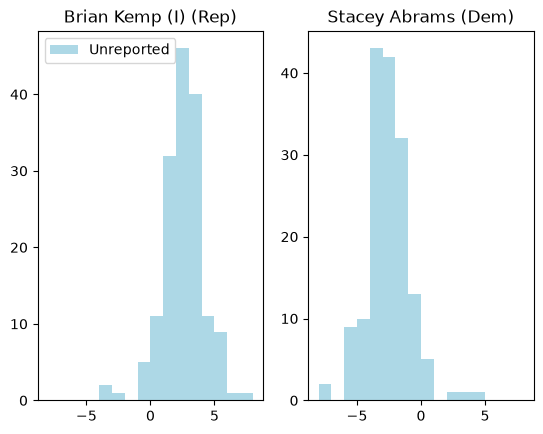

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def convt_to_shares(votes: pd.DataFrame, cands: list[str], group_by: str):
    shares = pd.DataFrame(votes)
    shares = shares.groupby(by=group_by).sum()
    shares['Total Votes'] = shares.index.map(lambda i: shares.loc[i].sum())
    for cand in cands:
        shares[cand] = shares[cand] / shares['Total Votes'] * 100
    return shares

def mk_swing(prev_shares: pd.DataFrame, curr_shares: pd.DataFrame):
    """Note: Does not count swings for third parties."""

    swings = pd.DataFrame(index=curr_shares.index)
    swings[curr_rep] = curr_shares[curr_rep] - prev_shares[prev_rep]
    swings[curr_dem] = curr_shares[curr_dem] - prev_shares[prev_dem]
    return swings

prev_shares_county = convt_to_shares(prev, prev_cands, 'County')
curr_shares_county = convt_to_shares(curr, curr_cands, 'County')

swings_county = mk_swing(prev_shares_county, curr_shares_county)

# Sanity check
assert len(swings_county) == 159

max_county_swing = swings_county.map(np.abs).max().max()
max_county_swing = int(np.ceil(max_county_swing))
range = (-max_county_swing, max_county_swing)
bins = max_county_swing * 2
fig, axes = plt.subplots(1, 2, squeeze=False)
for cand, ax in zip([curr_rep, curr_dem], axes[0]):
    ax.hist([swings_county[cand]], bins=bins, 
                    range=range, stacked=True, color=['lightblue'], 
                    label=['Unreported', 'Reported'])
    ax.set_title(cand)
l = axes[0][0].legend()

In [ ]:
import geopandas
import matplotlib.colors as mcolors

prev_shares_metro = convt_to_shares(prev_votes_metro, prev_cands, 'Reporting Group')
curr_shares_metro = convt_to_shares(curr_votes_metro, curr_cands, 'Reporting Group')

swings_metro = mk_swing(prev_shares_metro, curr_shares_metro)

curr_shares_county['geometry'] = swings_county['geometry'] = counties['geometry']
curr_shares_county = geopandas.GeoDataFrame(curr_shares_county)
curr_shares_metro['geometry'] = swings_metro['geometry'] = metro_prec_data_rg_map['geometry']
curr_shares_metro = geopandas.GeoDataFrame(curr_shares_metro)
#prev_shares_metro['geometry'] = metro_prec_data_rg_map['geometry']
#prev_shares_metro = geopandas.GeoDataFrame(prev_shares_metro)
swings_county = geopandas.GeoDataFrame(swings_county)
swings_metro = geopandas.GeoDataFrame(swings_metro)
fig, axes = plt.subplots(2, 2, figsize=(15,15), squeeze=True)

share_nm_ax = axes[0][0]
swing_nm_ax = axes[1][0]
share_metro_ax = axes[0][1]
swing_metro_ax = axes[1][1]

curr_shares_county['Region'] = swings_county['Region'] = counties['Region']
curr_shares_county['Subregion'] = swings_county['Subregion'] = counties['Subregion']
curr_shares_metro['Region'] = swings_metro['Region'] = metro_prec_data_rg_map['Region']
curr_shares_metro['Subregion'] = swings_metro['Subregion'] = metro_prec_data_rg_map['Subregion']
#prev_shares_metro['Subregion'] = metro_prec_data_rg_map['Subregion']
#prev_shares_metro['Region'] = metro_prec_data_rg_map['Region']

missing_kwds={
    'color': 'lightgray',
    'edgecolor': 'red',
    'hatch': '///',
    'label': 'Missing values'
}

bd_layer_1_w = 0.1
bd_layer_2_w = 1

# Share map
def plot_shares(shares: pd.DataFrame, candidate: str, candidate_lgnd_label: str, ax: geopandas.Axis, cmap):
    shares[shares[candidate] > 50]\
        .plot(column=candidate, ax=ax, #legend=True, 
            cmap=cmap, missing_kwds=missing_kwds,
            legend_kwds={'label': candidate_lgnd_label, 'orientation': 'horizontal'},
            norm=mcolors.Normalize(40, 100))

# County (non-Metro share) (top-left)
plot_shares(curr_shares_county, curr_rep, 'Kemp', share_nm_ax, 'OrRd')
plot_shares(curr_shares_county, curr_dem, 'Abrams', share_nm_ax, 'Blues')
curr_shares_county.dissolve(by='Subregion').plot(ax=share_nm_ax, color='none', linewidth=bd_layer_1_w)
curr_shares_county.dissolve(by='Region').plot(ax=share_nm_ax, color='none', linewidth=bd_layer_2_w)

# Metro share (top-right)
plot_shares(curr_shares_metro, curr_rep, 'Kemp', share_metro_ax, 'OrRd')
plot_shares(curr_shares_metro, curr_dem, 'Abrams', share_metro_ax, 'Blues')
curr_shares_metro.dissolve(by='Subregion').plot(ax=share_metro_ax, color='none', linewidth=bd_layer_1_w)
curr_shares_metro.dissolve(by='Region').plot(ax=share_metro_ax, color='none', linewidth=bd_layer_2_w)

# TPS Swing map
swings_county['TPS'] = swings_county[curr_dem] - swings_county[curr_rep] / 2
swings_metro['TPS'] = swings_metro[curr_dem] - swings_metro[curr_rep] / 2

swing_norm = mcolors.CenteredNorm(halfrange=20)

swings_county.plot(column='TPS', ax=swing_nm_ax, legend=True, 
                   norm=swing_norm, cmap='RdBu')
swings_county.dissolve(by='Subregion').plot(ax=swing_nm_ax, color='none', linewidth=bd_layer_1_w)
swings_county.dissolve(by='Region').plot(ax=swing_nm_ax, color='none', linewidth=bd_layer_2_w)

swings_metro.plot(column='TPS', ax=swing_metro_ax, legend=True, 
                  norm=swing_norm, cmap='RdBu')
swings_metro.dissolve(by='Subregion').plot(ax=swing_metro_ax, color='none', linewidth=bd_layer_1_w)
swings_metro.dissolve(by='Region').plot(ax=swing_metro_ax, color='none', linewidth=bd_layer_2_w)

#plot_shares(prev_shares_metro, prev_rep, 'Kemp', swing_metro_ax, 'OrRd')
#plot_shares(prev_shares_metro, prev_dem, 'Abrams', swing_metro_ax, 'Blues')
#prev_shares_metro.dissolve(by='Subregion').plot(ax=swing_metro_ax, color='none', linewidth=bd_layer_1_w)
#prev_shares_metro.dissolve(by='Region').plot(ax=swing_metro_ax, color='none', linewidth=bd_layer_2_w)

share_nm_ax.set_title('Share for Winning Candidate')
share_nm_ax.set_axis_off()
swing_nm_ax.set_title('Two-Party Swing')
swing_nm_ax.set_axis_off()
share_metro_ax.set_axis_off()
swing_metro_ax.set_axis_off()

TODO for preceeding: 
* Missing metro precincts
* Data centers
* Error margins
* Abstractify for all races

## Timeline

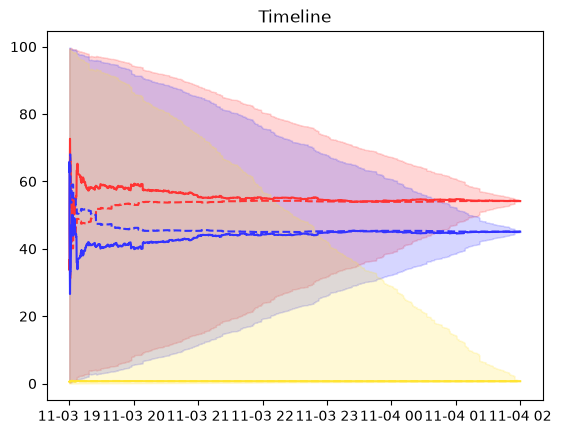

Brian Kemp (I) (Rep)                                   \
                                 Counted Projection Min. Share Max. Share   
Timestamp                                                                   
2026-11-03 19:00:02            36.611195  31.320333   0.271517  99.529895   
2026-11-03 19:00:03            33.713137  31.320333   0.271517  99.529895   
2026-11-03 19:00:05            33.690556  31.320333   0.271517  99.529895   
2026-11-03 19:00:15            33.779264  31.320333   0.271517  99.529895   
2026-11-03 19:00:18             52.99572  31.320333   0.271517  99.529895   
...                                  ...        ...        ...        ...   
2026-11-04 01:59:37            54.208428  54.191142  54.127708  54.309824   
2026-11-04 01:59:44            54.201056  54.191142  54.127708  54.309824   
2026-11-04 01:59:45            54.193777  54.191142  54.127708  54.309824   
2026-11-04 01:59:45            54.193777  54.191142  54.127708  54.309824   
2026-11-04 01:59:59             54.18769  54.191142  54.127708  54.309824   

                    Stacey Abrams (Dem)                                   \
                                Counted Projection Min. Share Max. Share   
Timestamp                                                                  
2026-11-03 19:00:02           62.859304  67.998631   0.466178  99.724557   
2026-11-03 19:00:03           65.817694  67.998631   0.466178  99.724557   
2026-11-03 19:00:05           65.840589  67.998631   0.466178  99.724557   
2026-11-03 19:00:15           65.752508  67.998631   0.466178  99.724557   
2026-11-03 19:00:18           46.398003  67.998631   0.466178  99.724557   
...                                 ...        ...        ...        ...   
2026-11-04 01:59:37           45.080645   45.09821  44.980222  45.162338   
2026-11-04 01:59:44           45.087797   45.09821  44.980222  45.162338   
2026-11-04 01:59:45           45.095247   45.09821  44.980222  45.162338   
2026-11-04 01:59:45           45.095247   45.09821  44.980222  45.162338   
2026-11-04 01:59:59           45.101367   45.09821  44.980222  45.162338   

                    Shane Hazel (Lib)                                   
                              Counted Projection Min. Share Max. Share  
Timestamp                                                               
2026-11-03 19:00:02          0.529501   0.681035   0.003927  99.262305  
2026-11-03 19:00:03          0.469169   0.681035   0.003927  99.262305  
2026-11-03 19:00:05          0.468855   0.681035   0.003927  99.262305  
2026-11-03 19:00:15          0.468227   0.681035   0.003927  99.262305  
2026-11-03 19:00:18          0.606277   0.681035   0.003927  99.262305  
...                               ...        ...        ...        ...  
2026-11-04 01:59:37          0.710927   0.710648   0.709954    0.89207  
2026-11-04 01:59:44          0.711147   0.710648   0.709954    0.89207  
2026-11-04 01:59:45          0.710976   0.710648   0.709954    0.89207  
2026-11-04 01:59:45          0.710976   0.710648   0.709954    0.89207  
2026-11-04 01:59:59          0.710943   0.710648   0.709954    0.89207  

[4304 rows x 12 columns]

In [66]:
out = pd.DataFrame(columns=pd.MultiIndex.from_product([curr_cands, ['Counted', 'Projection', 'Min. Share', 'Max. Share']]))

# Dummy
df_votes['Reported?'] = False
start_u = pd.to_datetime('2026-11-3T19:00:00').value // 10 ** 9
end_u = pd.to_datetime('2026-11-4T02:00:00').value // 10 ** 9
df_votes['Timestamp'] = pd.to_datetime(np.random.randint(start_u, end_u, len(df_votes)), unit='s')
#df_votes.loc[['Fulton', 'DeKalb'], 'Timestamp'] += pd.DateOffset(hours=3)

for i,timestamp in enumerate(np.sort(df_votes['Timestamp'].unique())):
    # Dummy
    df_votes['Reported?'] = df_votes['Timestamp'] <= timestamp
    results_table_at_t = display_single_results(df_votes[df_votes['Reported?']][curr_cands])
    if i % 10 == 0:
        df_votes_proj = project_m(df_votes, prev_cands, curr_cands, swing_map)
        stwd_proj_at_t = total_projection(df_votes_proj)
        # region range
        ix = df_votes_proj.reset_index('Field').index.unique()
        progress = pd.DataFrame([[df_votes_proj.loc[(*i, 'Projection')].sum(),
                                df_votes_proj.loc[(*i, 'Current')].sum()]
                                for i in ix], 
                                index=ix,
                                columns=['Projected Votes', 'Counted'])
        progress['Est. Remaining'] = progress['Projected Votes'] - progress['Counted']
        # There might be some logic in displaying this bc it could be helpful, but it's also bulky
        #progress.map(utils.format_votes)
        votes_in_doubt = progress['Est. Remaining'].sum()
        stwd_current_count = df_votes_proj.reset_index().groupby('Field')[curr_cands].sum().loc['Current']
        stwd_current_count = pd.DataFrame(stwd_current_count)
        stwd_current_count = stwd_current_count.rename(columns={'Current': 'Votes'})
        stwd_current_count = sort_and_share(stwd_current_count)

        total_projected = stwd_current_count['Votes'].sum() + votes_in_doubt
        ranges = pd.DataFrame(stwd_current_count, columns=['Votes', 'Share'])
        ranges['Min. Share'] = ranges['Votes'] / total_projected * 100
        ranges['Max. Share'] = (ranges['Votes'] + votes_in_doubt) / total_projected * 100
        # endregion

    # Updated reporting
    now_reporting = df_votes[df_votes['Reported?']].index

    # Sanity check
    prev_reported = out.index
    should_be_none = prev_reported[~prev_reported.isin(now_reporting)]
    if len(should_be_none) != 0:
        print(f'The following units were previously classified as reported and are now not:')
        for i in should_be_none:
            print(i)

    # Newly reporting
    newly_reporting = now_reporting[~now_reporting.isin(prev_reported)]
    if len(newly_reporting) == 0:
        assert False
        continue
    newly_reporting = pd.DataFrame(index=newly_reporting, columns=out.columns)

    for cand in curr_cands:
        newly_reporting[cand, 'Counted'] = results_table_at_t.loc[cand, 'Share']
        newly_reporting[cand, 'Projection'] = stwd_proj_at_t.loc[cand, 'Share']
        newly_reporting[cand, 'Min. Share'] = ranges.loc[cand, 'Min. Share']
        newly_reporting[cand, 'Max. Share'] = ranges.loc[cand, 'Max. Share']
    newly_reporting['Timestamp'] = timestamp

    out = pd.concat([out, newly_reporting])

# For plot
out_plt = out.set_index('Timestamp')
fig, ax = plt.subplots()
for cand in curr_cands:
    party = cand[-4:-1]
    color = {
        'Rep': '#ff3333',
        'Dem': '#3333ff',
        'Lib': "#ffe433"
    }[party]
    ax.plot(out_plt[(cand, 'Counted')], color=color, linestyle='solid')
    ax.plot(out_plt[(cand, 'Projection')], color=color, linestyle='dashed')
    ax.fill_between(out_plt.index, 
                    np.array(out_plt[(cand, 'Min. Share')], dtype=float), 
                    np.array(out_plt[(cand, 'Max. Share')], dtype=float), 
                    alpha=0.2, color=color)
ax.set_title('Timeline')
plt.show()
out_plt